In [2]:
import nupack as nu 
import numpy as np 
from seqwalk import design
import math
import sys
import random 
import csv
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from tqdm import tqdm

# import custom modules
if 'barcodes' in sys.modules:
    del sys.modules['barcodes']
if 'toeholds' in sys.modules:
    del sys.modules['toeholds']
if 'finalize_seqs' in sys.modules:
    del sys.modules['finalize_seqs']
if 'analysis' in sys.modules:
    del sys.modules['analysis']

from orthogonal import *
from barcodes import *
from toeholds import *
from finalize_seqs import *
from analysis import *

In [3]:
def load(filename, barcode_length, toehold_length):

    barcodes = []
    toeholds = []
    toeholds_seqs = [] 
    pairings = []
    pairings_seqs = []

    with open(filename, "r",encoding='utf-8-sig') as f:
        reader = csv.reader(f)
        row = next(reader, None)
        while row is not None:
            next_row = next(reader, None)
            if row[1] == "top" and next_row[1] == "top":
                barcode = row[3][-barcode_length:]
                toehold = row[3][-(barcode_length+toehold_length):-barcode_length]
                barcodes.append(barcode)
                toeholds_seqs.append(toehold)
                toeholds.append((toehold,0))
                pairings.append((toehold, barcode))
                pairings_seqs.append(toehold + barcode)
            row = next_row
    
    return barcodes, toeholds, toeholds_seqs, pairings, pairings_seqs

# settings 
barcode_length = 18
toehold_length = 10

# analysis of sidewinder pools

In [7]:
model =nu.Model(material="dna", celsius=50)
ncores = mp.cpu_count()
conc = 1e-8


## String 24 Pool: 100mer

In [12]:
filename = "string_24_pool_100mer.csv"
barcodes, toeholds, toeholds_seqs, pairings, pairings_seqs = load(filename, barcode_length, toehold_length)
toehold_data = evaluate_combinations(toeholds_seqs, model, conc, ncores)
barcode_data = evaluate_barcodes(barcodes, toeholds_seqs, model, conc, ncores)
evaluated_pairings = evaluate_pairings(pairings_seqs, model, ncores)

print(toehold_data)
print(barcode_data)
print(evaluated_pairings)



75855it [00:03, 19377.36it/s]                  
100%|██████████| 390/390 [00:01<00:00, 206.27it/s]

(2.7789917316786297, 10.663775705983278, 0.30931559144703313, 1.5391746840338093e-05, 0.42804712019255325, 0.14822743788663187, 0.12319816406085167, 0.9680893077371169)
(5.0, 10.394107178168875, 0.035040278612331215, 0.9547744321576733, 0.46545369798523234, 2.2792201635401824e-05, 0.7430510998622152, 0.18237414514563993, 0.34651866117128666, 0.9863455581700677)
(10, 0.5682435010413355, 0.22223953073031708)


In [13]:
strings = []
for i in range(len(pairings_seqs)):
    strings.append(pairings_seqs[i])
duplex = True
string_nu_mat, string_on_t = nupack_matrix_mp(strings, model, conc, ncores, duplex)
string_off_target_ensemble, string_on_target_ensemble = ensemble_matrix_mp(strings, model, 
                                                                 ncores, duplex)

print(np.max(string_on_target_ensemble))
print(np.min(string_off_target_ensemble))
print(np.min(string_on_t))
print(np.max(string_nu_mat))

Generating...



100%|██████████| 390/390 [00:48<00:00,  8.00it/s]

Generating...




100%|██████████| 390/390 [00:58<00:00,  6.65it/s]

0.5682435010413356
0.5440158865635819
0.9938797516801788
0.9250338907381286


In [38]:
print(np.max(string_on_target_ensemble))
print(np.min(string_off_target_ensemble))
print(np.min(string_on_t))
print(np.max(string_nu_mat))

0.5682435010413356
0.5440158865635819
0.9938797516801788
0.9250338907381286


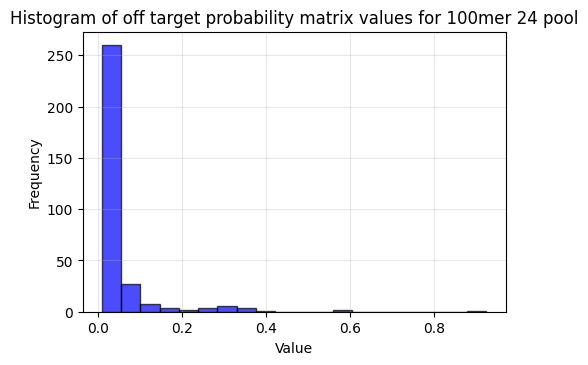

In [14]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(string_nu_mat[np.where(string_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of off target probability matrix values for 100mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

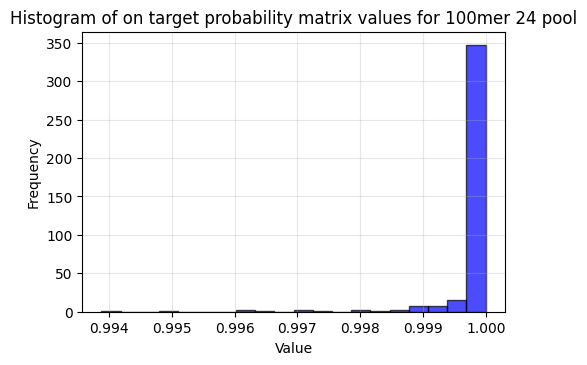

In [15]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(string_on_t.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target probability matrix values for 100mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

## String 24 Pool: 165mer

In [16]:
filename = "string_24_pool_165mer.csv"
s24165_barcodes, s24165_toeholds, s24165_toeholds_seqs, s24165_pairings, s24165_pairings_seqs = load(filename, barcode_length, toehold_length)
s24165_toehold_data = evaluate_combinations(s24165_toeholds_seqs, model, conc, ncores)
s24165_barcode_data = evaluate_barcodes(s24165_barcodes, s24165_toeholds_seqs, model, conc, ncores)
s24165_evaluated_pairings = evaluate_pairings(s24165_pairings_seqs, model, ncores)

print(s24165_toehold_data)
print(s24165_barcodes)
print(s24165_evaluated_pairings)



10296it [00:01, 5415.18it/s]                   
100%|██████████| 144/144 [00:01<00:00, 84.58it/s]

(3.1545975074625465, 10.687345053137454, 0.02430872438046438, 1.3457953250274738e-05, 0.5860583275711427, 0.15111585466422994, 0.20611746443787285, 0.9685709058360139)
['TTGGGCATCTCTTCAGCG', 'CAGCGTTCTACACCCGCC', 'GGTGTCCGACCGCCCTAT', 'TGAACTAACAGTAAGCTA', 'ATATCTAGGCTATAAGGA', 'AACTCCCGTGTCACTTGT', 'GGTTGTAAGATTCTACCC', 'CAGGACAGTACGCGCACC', 'GTGCCGCGGTTTGAGTGC', 'TACGTGAGGCCAGCGATG', 'CCCGCTTGCTCCGCGGAT', 'TTGTGCTTATTTAGCTCA', 'ACCGGTTTAATCTATTAG', 'AGGTTGTACTGTAAGTAT', 'CAATTGGGCGGTTTGGAA', 'GTTAGAAAGTATATCTAA', 'TACCTGCAAGAAGTAAGC', 'TGAGGCAGACAATCTCAG', 'TGACTCAGGGGCTGCGAC', 'GATCGCGGGGTAGCAATA', 'TGTGCGGGAATCTTTGGT', 'CACAGGGTGTGCCGTCTT', 'TCCGCACTTGAATGGACT', 'TCTGGCCATTGCTTATAT', 'TACTTGATTTTGGCGTTT', 'TGTTTTCTGCGCCGGTCG', 'CCACCCCGTTAGGAAATC', 'ACGTAATTTAAAGGAATC', 'TGTGCCCTCAAGAGGCCT', 'CTACAGAACTCCTAATAA', 'TAAGGCGATATGACAGTT', 'GCAGTTGATAGCATCCTG', 'GAGGTGTGGTTTACCCCC', 'CGTCGGGGAGGACGTTGA', 'GTTCGAATCAAGTTCAGA', 'GGCTCTTTCGTACGACTC', 'CTTATATTATATTAGTCT', 'CCTACGTTTCCATACA

In [39]:
print(s24165_barcode_data)

(6.0, 10.483197358197359, 0.020171410575273396, 0.9508217854271953, 0.10327638146665699, 2.260378734082579e-05, 0.5181984974275464, 0.1761499725487734, 0.5134057675873765, 0.9868281506447844)


In [17]:
print(s24165_toehold_data)
print(s24165_barcodes)
print(s24165_evaluated_pairings)

(3.1545975074625465, 10.687345053137454, 0.02430872438046438, 1.3457953250274738e-05, 0.5860583275711427, 0.15111585466422994, 0.20611746443787285, 0.9685709058360139)
['TTGGGCATCTCTTCAGCG', 'CAGCGTTCTACACCCGCC', 'GGTGTCCGACCGCCCTAT', 'TGAACTAACAGTAAGCTA', 'ATATCTAGGCTATAAGGA', 'AACTCCCGTGTCACTTGT', 'GGTTGTAAGATTCTACCC', 'CAGGACAGTACGCGCACC', 'GTGCCGCGGTTTGAGTGC', 'TACGTGAGGCCAGCGATG', 'CCCGCTTGCTCCGCGGAT', 'TTGTGCTTATTTAGCTCA', 'ACCGGTTTAATCTATTAG', 'AGGTTGTACTGTAAGTAT', 'CAATTGGGCGGTTTGGAA', 'GTTAGAAAGTATATCTAA', 'TACCTGCAAGAAGTAAGC', 'TGAGGCAGACAATCTCAG', 'TGACTCAGGGGCTGCGAC', 'GATCGCGGGGTAGCAATA', 'TGTGCGGGAATCTTTGGT', 'CACAGGGTGTGCCGTCTT', 'TCCGCACTTGAATGGACT', 'TCTGGCCATTGCTTATAT', 'TACTTGATTTTGGCGTTT', 'TGTTTTCTGCGCCGGTCG', 'CCACCCCGTTAGGAAATC', 'ACGTAATTTAAAGGAATC', 'TGTGCCCTCAAGAGGCCT', 'CTACAGAACTCCTAATAA', 'TAAGGCGATATGACAGTT', 'GCAGTTGATAGCATCCTG', 'GAGGTGTGGTTTACCCCC', 'CGTCGGGGAGGACGTTGA', 'GTTCGAATCAAGTTCAGA', 'GGCTCTTTCGTACGACTC', 'CTTATATTATATTAGTCT', 'CCTACGTTTCCATACA

In [18]:
s24165_strings = []
for i in range(len(s24165_pairings_seqs)):
    s24165_strings.append(s24165_pairings_seqs[i])
duplex = True
s24165_nu_mat, s24165_on_t = nupack_matrix_mp(s24165_strings, model, conc, ncores, duplex)
s24165_off_target_ensemble, s24165_on_target_ensemble = ensemble_matrix_mp(s24165_strings, model, 
                                                                 ncores, duplex)

print(np.max(s24165_on_target_ensemble))
print(np.min(s24165_off_target_ensemble))
print(np.min(s24165_on_t))
print(np.max(s24165_nu_mat))

Generating...



100%|██████████| 144/144 [00:07<00:00, 18.89it/s]

Generating...




100%|██████████| 144/144 [00:09<00:00, 15.44it/s]

0.47541929447825865
0.632551325532928
0.998180526650703
0.3443430219578246


In [40]:
print(np.max(s24165_on_target_ensemble))
print(np.min(s24165_off_target_ensemble))
print(np.min(s24165_on_t))
print(np.max(s24165_nu_mat))

0.47541929447825865
0.632551325532928
0.998180526650703
0.3443430219578246


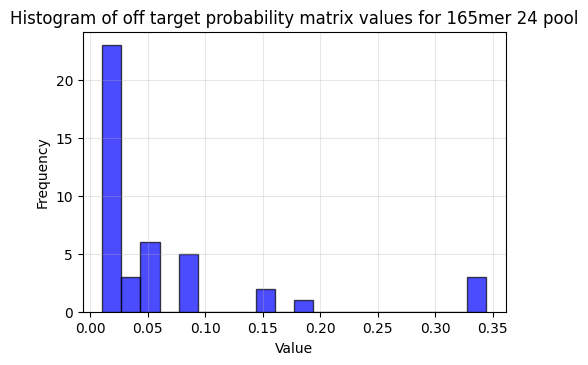

In [19]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(s24165_nu_mat[np.where(s24165_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of off target probability matrix values for 165mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

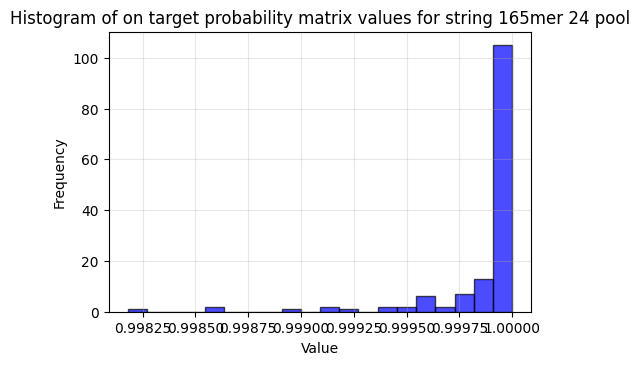

In [20]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(s24165_on_t.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target probability matrix values for string 165mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

## String 94 Pool: 100mer

In [8]:
filename = "string_94_pool_100mer.csv"
s94100_barcodes, s94100_toeholds, s94100_toeholds_seqs, s94100_pairings, s94100_pairings_seqs = load(filename, barcode_length, toehold_length)
s94100_toehold_data = evaluate_combinations(s94100_toeholds_seqs, model, conc, ncores)
s94100_barcode_data = evaluate_barcodes(s94100_barcodes, s94100_toeholds_seqs, model, conc, ncores)
s94100_evaluated_pairings = evaluate_pairings(s94100_pairings_seqs, model, ncores)

print(s94100_toehold_data)
print(s94100_barcode_data)
print(s94100_evaluated_pairings)

1644391it [00:52, 31541.89it/s]                 
100%|██████████| 1814/1814 [00:03<00:00, 595.78it/s] 

(1.3678794411714423, 10.59754001887254, 0.6390238015316309, 1.8290899071764096e-05, 0.5111294494842963, 0.14419059278815635, 0.11219342811279417, 0.9663108069133327)
(4.0, 10.422676236977702, 0.0038677827270373996, 0.9537202984168749, 0.41721837178106475, 2.54823476940437e-05, 0.6613410182553214, 0.1847141854320737, 0.2910063002837724, 0.9868621597365591)
(12, 0.6326005008689402, 0.2241936345473276)


In [9]:
s94100_strings = []
for i in range(len(s94100_pairings_seqs)):
    s94100_strings.append(s94100_pairings_seqs[i])
duplex = True
s94100_nu_mat, s94100_on_t = nupack_matrix_mp(s94100_strings, model, conc, ncores, duplex)
s94100_off_target_ensemble, s94100_on_target_ensemble = ensemble_matrix_mp(s94100_strings, model, 
                                                                 ncores, duplex)

print(np.max(s94100_on_target_ensemble))
print(np.min(s94100_off_target_ensemble))
print(np.min(s94100_on_t))
print(np.max(s94100_nu_mat))

Generating...



100%|██████████| 1814/1814 [18:32<00:00,  1.63it/s] 

Generating...




100%|██████████| 1814/1814 [21:28<00:00,  1.41it/s] 

0.6326005008689402
0.42459793077159375
0.9649150312031974
0.9427402199921148


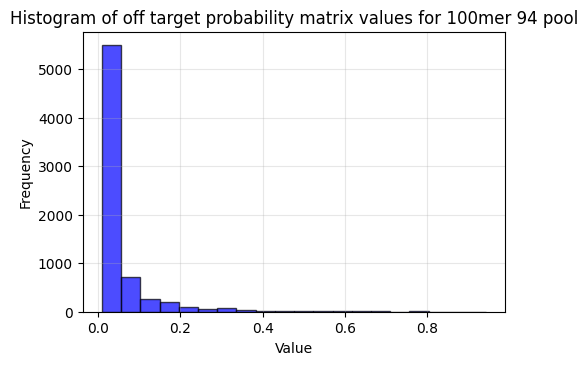

In [10]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(s94100_nu_mat[np.where(s94100_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of off target probability matrix values for 100mer 94 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

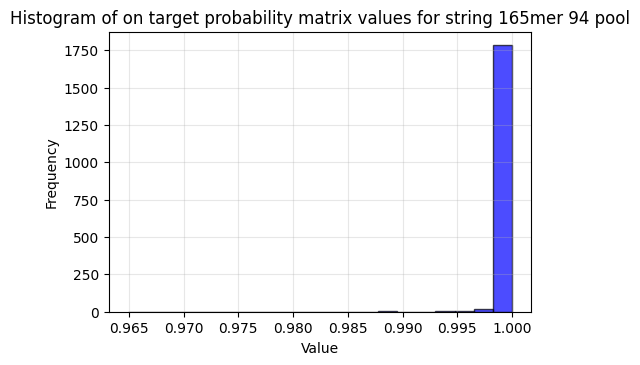

In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(s94100_on_t.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target probability matrix values for string 165mer 94 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

## String 94 Pool: 165mer

In [21]:
filename = "string_94_pool_165mer.csv"
s94165_barcodes, s94165_toeholds, s94165_toeholds_seqs, s94165_pairings, s94165_pairings_seqs = load(filename, barcode_length, toehold_length)
s94165_toehold_data = evaluate_combinations(s94165_toeholds_seqs, model, conc, ncores)
s94165_barcode_data = evaluate_barcodes(s94165_barcodes, s94165_toeholds_seqs, model, conc, ncores)
s94165_evaluated_pairings = evaluate_pairings(s94165_pairings_seqs, model, ncores)

print(s94165_toehold_data)
print(s94165_barcode_data)
print(s94165_evaluated_pairings)



221445it [00:08, 26231.21it/s]                 
100%|██████████| 666/666 [00:02<00:00, 305.16it/s]

(1.4111122905071873, 10.65998101773134, 0.22201955616341468, 1.9908113143003582e-05, 0.5000978375615097, 0.14803296191552584, 0.09624083061288254, 0.9669825410063172)
(4.0, 10.237625595520333, 0.0015379511071120203, 0.9408842500912773, 0.5085675044887397, 1.8798556681070085e-05, 0.6515013837314115, 0.18610630660000185, 0.36066108150908416, 0.9868590690933388)
(11, 0.5657651911177974, 0.21306793945366603)


In [22]:

print(s94165_toehold_data)
print(s94165_barcode_data)
print(s94165_evaluated_pairings)

(1.4111122905071873, 10.65998101773134, 0.22201955616341468, 1.9908113143003582e-05, 0.5000978375615097, 0.14803296191552584, 0.09624083061288254, 0.9669825410063172)
(4.0, 10.237625595520333, 0.0015379511071120203, 0.9408842500912773, 0.5085675044887397, 1.8798556681070085e-05, 0.6515013837314115, 0.18610630660000185, 0.36066108150908416, 0.9868590690933388)
(11, 0.5657651911177974, 0.21306793945366603)


In [51]:
s94165_strings == s94165_pairings_seqs

True

In [23]:
s94165_strings = []
for i in range(len(s94165_pairings_seqs)):
    s94165_strings.append(s94165_pairings_seqs[i])
duplex = True
s94165_nu_mat, s94165_on_t = nupack_matrix_mp(s94165_strings, model, conc, ncores, duplex)
s94165_off_target_ensemble, s94165_on_target_ensemble = ensemble_matrix_mp(s94165_strings, model, 
                                                                 ncores, duplex)

print(np.max(s94165_on_target_ensemble))
print(np.min(s94165_off_target_ensemble))
print(np.min(s94165_on_t))
print(np.max(s94165_nu_mat))

Generating...



100%|██████████| 666/666 [02:31<00:00,  4.41it/s]

Generating...




100%|██████████| 666/666 [02:52<00:00,  3.85it/s]

0.5657651911177976
0.5541868050467674
0.9855644932137065
0.8268308964680143


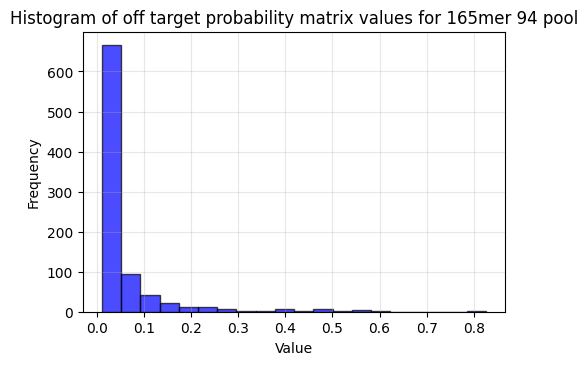

In [24]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(s94165_nu_mat[np.where(s94165_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of off target probability matrix values for 165mer 94 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

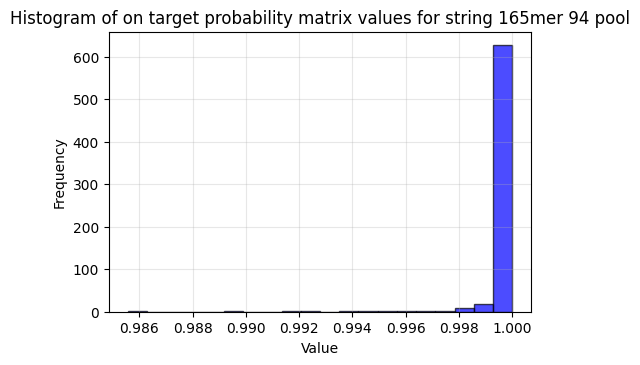

In [25]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(s94165_on_t.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target probability matrix values for string 165mer 94 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

## Thermo 24 Pool: 100mer

In [26]:
filename = "thermo_24_pool_100mer.csv"
t24100_barcodes, t24100_toeholds, t24100_toeholds_seqs, t24100_pairings, t24100_pairings_seqs = load(filename, barcode_length, toehold_length)
t24100_toehold_data = evaluate_combinations(t24100_toeholds_seqs, model, conc, ncores)
t24100_barcode_data = evaluate_barcodes(t24100_barcodes, t24100_toeholds_seqs, model, conc, ncores)
t24100_evaluated_pairings = evaluate_pairings(t24100_pairings_seqs, model, ncores)

print(t24100_toehold_data)
print(t24100_barcode_data)
print(t24100_evaluated_pairings)

75855it [00:03, 19583.83it/s]                  
100%|██████████| 390/390 [00:01<00:00, 204.52it/s]

(1.513417119032592, 10.628512202199676, 0.025597368480140797, 8.55496918972069e-06, 0.42562305503520115, 0.14377468214707054, 0.17520952374637916, 0.9678276339741115)
(5.0, 10.348309274273285, 0.14324021964302389, 0.9555401923712225, 0.18600290295047353, 1.801534049647707e-05, 0.5286444790070504, 0.1828786806232022, 0.4381061035300397, 0.9866643678405184)
(10, 0.4597552204151047, 0.212916942259818)


In [27]:
t24100_strings = []
for i in range(len(t24100_pairings_seqs)):
    t24100_strings.append(t24100_pairings_seqs[i])
duplex = True
t24100_nu_mat, t24100_on_t = nupack_matrix_mp(t24100_strings, model, conc, ncores, duplex)
t24100_off_target_ensemble, t24100_on_target_ensemble = ensemble_matrix_mp(t24100_strings, model, 
                                                                 ncores, duplex)

print(np.max(t24100_on_target_ensemble))
print(np.min(t24100_off_target_ensemble))
print(np.min(t24100_on_t))
print(np.max(t24100_nu_mat))

Generating...



100%|██████████| 390/390 [00:49<00:00,  7.84it/s]

Generating...




100%|██████████| 390/390 [01:00<00:00,  6.44it/s]


0.46445060723834636
0.44946245748708274
0.9900724227572946
0.9283344254552038


In [41]:
print(np.max(t24100_on_target_ensemble))
print(np.min(t24100_off_target_ensemble))
print(np.min(t24100_on_t))
print(np.max(t24100_nu_mat))

0.46445060723834636
0.44946245748708274
0.9900724227572946
0.9283344254552038


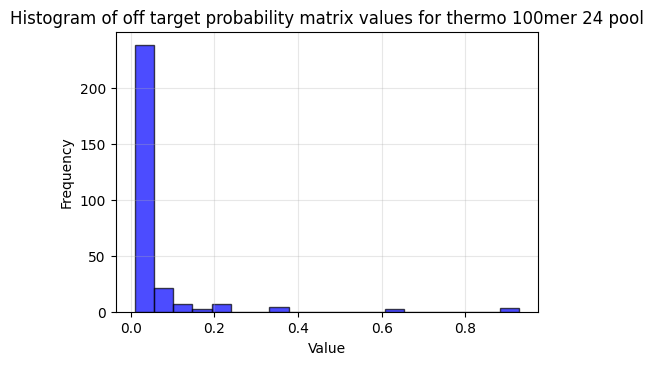

In [28]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t24100_nu_mat[np.where(t24100_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of off target probability matrix values for thermo 100mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

In [64]:
r = np.argmax(t24100_nu_mat) % np.shape(t24100_nu_mat)[1]
c = np.argmax(t24100_nu_mat) // np.shape(t24100_nu_mat)[1]

print(r, c)

print(t24100_nu_mat[r, c])
print(t24100_strings[r])

269 269
0.9283344254552038
CAACTGGATCGGCGCCGATATACTCCCG


In [66]:
 
np.argmax(t24165_on_target_ensemble)

128

In [67]:
t24165_strings[np.argmax(t24165_on_target_ensemble)]

'CCTCTCGCTGCCCACATTTGCTCGAGAT'

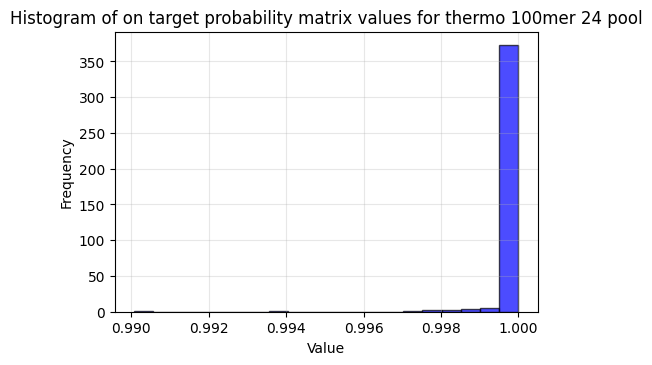

In [29]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t24100_on_t.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target probability matrix values for thermo 100mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

## Thermo 24 Pool: 165mer

In [47]:
filename = "string_94_pool_165mer.csv"
s94165_barcodes, s94165_toeholds, s94165_toeholds_seqs, s94165_pairings, s94165_pairings_seqs = load(filename, barcode_length, toehold_length)
s94165_toehold_data = evaluate_combinations(s94165_toeholds_seqs, model, conc, ncores)
s94165_barcode_data = evaluate_barcodes(s94165_barcodes, s94165_toeholds_seqs, model, conc, ncores)
s94165_evaluated_pairings = evaluate_pairings(s94165_pairings_seqs, model, ncores)

print(s94165_toehold_data)
print(s94165_barcode_data)
print(s94165_evaluated_pairings)



filename = "thermo_24_pool_165mer.csv"
t24165_barcodes, t24165_toeholds, t24165_toeholds_seqs, t24165_pairings, t24165_pairings_seqs = load(filename, barcode_length, toehold_length)
t24165_toehold_data = evaluate_combinations(t24165_toeholds_seqs, model, conc, ncores)
t24165_barcode_data = evaluate_barcodes(t24165_barcodes, t24165_toeholds_seqs, model, conc, ncores)
t24165_evaluated_pairings = evaluate_pairings(t24165_pairings_seqs, model, ncores)

print(t24165_toehold_data)
print(t24165_barcode_data)
print(t24165_evaluated_pairings)

10296it [00:01, 5365.88it/s]                   
100%|██████████| 144/144 [00:01<00:00, 79.46it/s] 

(2.881296560204034, 10.621288419341518, 0.0028744732202225886, 7.11424132742115e-06, 0.35468441306462745, 0.14080736304751115, 0.3260482806679456, 0.9683675338218928)
(5.0, 10.416278166278166, 0.1503944213252808, 0.9594256294008395, 0.021561818199488263, 1.3179559185193913e-05, 0.47347992991278, 0.16839296849794297, 0.5483284859423324, 0.9874965233400296)
(9, 0.3811701901009674, 0.2037834976928124)


In [59]:
evaluate_pairings(t24165_pairings_seqs, model, ncores)

100%|██████████| 144/144 [00:01<00:00, 94.60it/s]


(9, 0.3811701901009674, 0.2037834976928124)

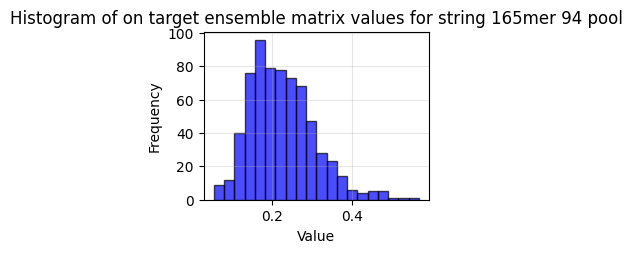

In [72]:
s94165_strings[np.argmax(s94165_on_target_ensemble)]

plt.subplot(2, 2, 1)
plt.hist(s94165_on_target_ensemble.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target ensemble matrix values for string 165mer 94 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)


In [31]:
t24165_strings = []
for i in range(len(t24165_pairings_seqs)):
    t24165_strings.append(t24165_pairings_seqs[i])
duplex = True
t24165_nu_mat, t24165_on_t = nupack_matrix_mp(t24165_strings, model, conc, ncores, duplex)
t24165_off_target_ensemble, t24165_on_target_ensemble = ensemble_matrix_mp(t24165_strings, model, 
                                                                 ncores, duplex)

print(np.max(t24165_on_target_ensemble))
print(np.min(t24165_off_target_ensemble))
print(np.min(t24165_on_t))
print(np.max(t24165_nu_mat))

Generating...



100%|██████████| 144/144 [00:08<00:00, 17.87it/s]

Generating...




100%|██████████| 144/144 [00:09<00:00, 14.84it/s]

0.4028713302360707
0.5802266455698907
0.9989543834468132
0.28689920736785496


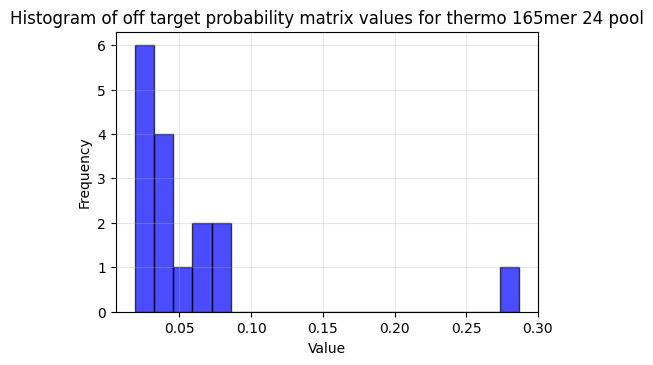

In [32]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t24165_nu_mat[np.where(t24165_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of off target probability matrix values for thermo 165mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

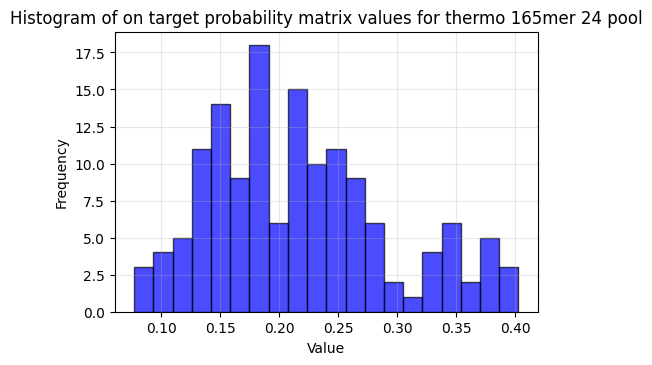

In [68]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t24165_on_target_ensemble.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target probability matrix values for thermo 165mer 24 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

## Thermo 94 Pool: 165mer

In [34]:
filename = "thermo_94_pool_165mer.csv"
t94165_barcodes, t94165_toeholds, t94165_toeholds_seqs, t94165_pairings, t94165_pairings_seqs = load(filename, barcode_length, toehold_length)
t94165_toehold_data = evaluate_combinations(t94165_toeholds_seqs, model, conc, ncores)
t94165_barcode_data = evaluate_barcodes(t94165_barcodes, t94165_toeholds_seqs, model, conc, ncores)
t94165_evaluated_pairings = evaluate_pairings(t94165_pairings_seqs, model, ncores)

print(t94165_toehold_data)
print(t94165_barcode_data)
print(t94165_evaluated_pairings)

221445it [00:08, 26295.90it/s]                 
100%|██████████| 666/666 [00:02<00:00, 326.64it/s]

(1.3678794411714423, 10.639241993050208, 0.10735862326833623, 1.5971306332951694e-05, 0.49707179266922646, 0.14235272240021057, 0.11664627493418714, 0.9669544345490291)
(4.0, 10.258642100747364, 0.016832176715793467, 0.9406752810233378, 0.21135753795477694, 1.6073214754936555e-05, 0.5443640517487776, 0.179328943387209, 0.31990183020198615, 0.987171867584814)
(12, 0.4778500764544731, 0.21285894903367722)


In [35]:
t94165_strings = []
for i in range(len(t94165_pairings_seqs)):
    t94165_strings.append(t94165_pairings_seqs[i])
duplex = True
t94165_nu_mat, t94165_on_t = nupack_matrix_mp(t94165_strings, model, conc, ncores, duplex)
t94165_off_target_ensemble, t94165_on_target_ensemble = ensemble_matrix_mp(t94165_strings, model, 
                                                                 ncores, duplex)

print(np.max(t24165_on_target_ensemble))
print(np.min(t94165_off_target_ensemble))
print(np.min(t94165_on_t))
print(np.max(t94165_nu_mat))

Generating...



100%|██████████| 666/666 [02:31<00:00,  4.38it/s]

Generating...




100%|██████████| 666/666 [02:54<00:00,  3.82it/s]

0.4028713302360707
0.4327914639896119
0.9706615851886524
0.7155873751939232


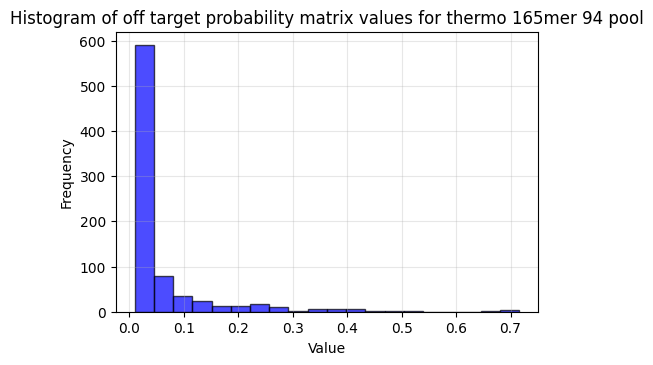

In [36]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t94165_nu_mat[np.where(t94165_nu_mat > 0.01)].flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of off target probability matrix values for thermo 165mer 94 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

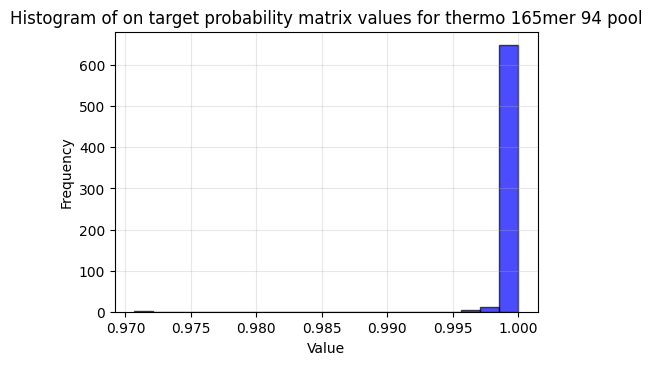

In [37]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(t94165_on_t.flatten(), bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of on target probability matrix values for thermo 165mer 94 pool')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

## Nupack 175mer 24 pool

In [43]:
nupack_filename = "F24_175mer_defect0.999 (1).csv"

nu_barcodes = []
nu_toeholds = []
nu_toeholds_seqs = [] 
nu_pairings = []
nu_pairings_seqs = []

with open(nupack_filename, "r",encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
       if i % 2 == 1:
            barcode = row[1][-barcode_length:]
            toehold = row[1][-(barcode_length+toehold_length):-barcode_length]
            nu_barcodes.append(barcode)
            nu_toeholds_seqs.append(toehold)
            nu_toeholds.append((toehold,0))
            nu_pairings.append((toehold, barcode))
            nu_pairings_seqs.append(toehold + barcode)

In [44]:
nu_toehold_data = evaluate_combinations(nu_toeholds_seqs, model, conc, ncores)

nu_barcode_data = evaluate_barcodes(nu_barcodes, nu_toeholds_seqs, model, conc, ncores)

nu_evaluated_pairings = evaluate_pairings(nu_pairings_seqs, my_model=model, ncores=ncores)

print(nu_toehold_data)
print(nu_barcode_data)
print(nu_evaluated_pairings)

8385it [00:03, 2123.44it/s]                    
100%|██████████| 130/130 [00:01<00:00, 75.41it/s]

(1.5737534207374329, 10.557141905069424, 0.047659966821249004, 2.0103810195936857e-05, 0.255241212711854, 0.13159436537100838, 0.3250686386274749, 0.9662497705573252)
(4.0, 10.515682766845558, 0.3279606308509117, 0.9567504216044259, 0.11717876546970897, 2.7033207777516906e-05, 0.4772569538847144, 0.1072684792230768, 0.4566008706796791, 0.9874872151475969)
(11, 0.4743378794576248, 0.12403408735581796)


In [45]:
nus = []
for i in range(len(nu_pairings)):
    nus.append(nu_pairings[i][0] + nu_pairings[i][1])
duplex = True
nu_nu_mat, nu_on_t = nupack_matrix_mp(nus, model, conc, ncores, duplex)
nu_off_target_ensemble, nu_on_target_ensemble = ensemble_matrix_mp(nus, model, 
                                                                 ncores, duplex)

Generating...



100%|██████████| 130/130 [00:06<00:00, 20.96it/s]

Generating...




100%|██████████| 130/130 [00:07<00:00, 17.35it/s]


In [46]:
print(np.max(nu_on_target_ensemble))
print(np.min(nu_off_target_ensemble))
print(np.min(nu_on_t))
print(np.max(nu_nu_mat))


0.474337879457625
0.585219915600472
0.9983661814696355
0.09995435120612212
